# Classification Analysis


In [51]:
import sys
sys.path.append('..')

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from bookrec import db

conn = db.get_connection()

df_raw = pd.read_sql("""
    SELECT id, title, author, genre, rating, description, tags
    FROM books
    WHERE description IS NOT NULL AND description != ''
""", conn)

df_raw['tags'] = df_raw['tags'].apply(
    lambda x: x if isinstance(x, dict) else (json.loads(x) if x else {})
)

print(f"Total books with descriptions: {len(df_raw):,}")
df_raw.head(3)

Total books with descriptions: 3,587


,id,title,author,genre,rating,description,tags
0,818,Черный лебедь. Под знаком непредсказуемости,Нассим Николас Талеб,Философия,3.9,За одно только последнее десятилетие человечес...,"{'topics': [], 'topic_label': 'Научная фантаст..."
1,153,После тебя,Джоджо Мойес,Зарубежная литература,3.9,"Что ты будешь делать, потеряв любимого человек...","{'topics': [], 'topic_label': 'Женские судьбы,..."
2,216,Икабог,Джоан Роулинг,Зарубежная литература,4.1,"Новая добрая, захватывающая история Дж. К. Роу...","{'topics': [], 'topic_label': 'Приключения и т..."


## 1. Coverage

Classification coverage
----------------------------------------
  zero_shot        2,938  (81.9%)
  bertopic           649  (18.1%)
  TOTAL            3,587


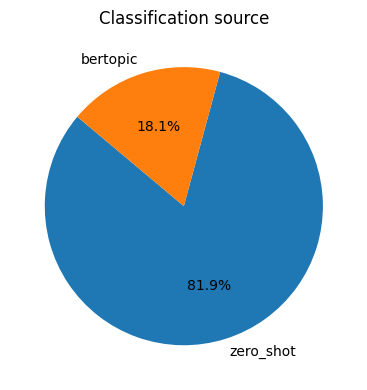

In [52]:
def classify_source(tags):
    if not tags:
        return 'unclassified'
    if tags.get('topic_label'):
        return 'bertopic'
    if tags.get('topics'):
        return 'zero_shot'
    return 'unclassified'

df_raw['source'] = df_raw['tags'].apply(classify_source)

counts = df_raw['source'].value_counts()
total = len(df_raw)

print('Classification coverage')
print('-' * 40)
for src, n in counts.items():
    print(f'  {src:<15} {n:>6,}  ({100*n/total:.1f}%)')
print(f"  {'TOTAL':<15} {total:>6,}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=140)
ax.set_title('Classification source')
plt.tight_layout()
plt.show()

## 2. Zero-shot confidence distribution

Zero-shot classified books : 2,938
(book, theme) pairs above threshold: 23,817
Avg themes per book: 8.11


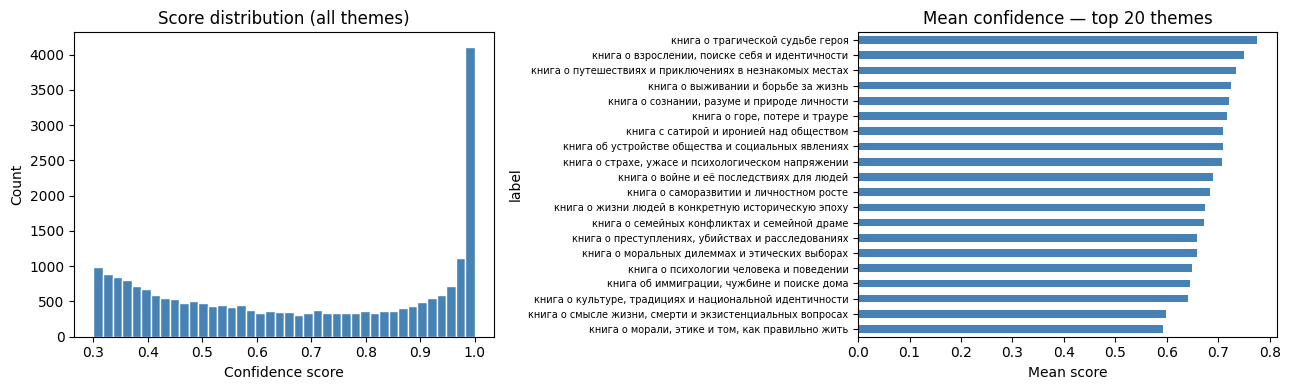

In [53]:
df_zs = df_raw[df_raw['source'] == 'zero_shot'].copy()

rows = []
for _, row in df_zs.iterrows():
    for t in row['tags'].get('topics', []):
        rows.append({'book_id': row['id'], 'label': t['label'], 'score': t['score']})

df_scores = pd.DataFrame(rows)

print(f"Zero-shot classified books : {len(df_zs):,}")
print(f"(book, theme) pairs above threshold: {len(df_scores):,}")
print(f"Avg themes per book: {len(df_scores)/max(len(df_zs),1):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_scores['score'], bins=40, edgecolor='white', color='steelblue')
axes[0].set_title('Score distribution (all themes)')
axes[0].set_xlabel('Confidence score')
axes[0].set_ylabel('Count')

top_themes = df_scores['label'].value_counts().head(20).index
theme_stats = (
    df_scores[df_scores['label'].isin(top_themes)]
    .groupby('label')['score']
    .mean()
    .sort_values()
)
theme_stats.plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Mean confidence — top 20 themes')
axes[1].set_xlabel('Mean score')
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

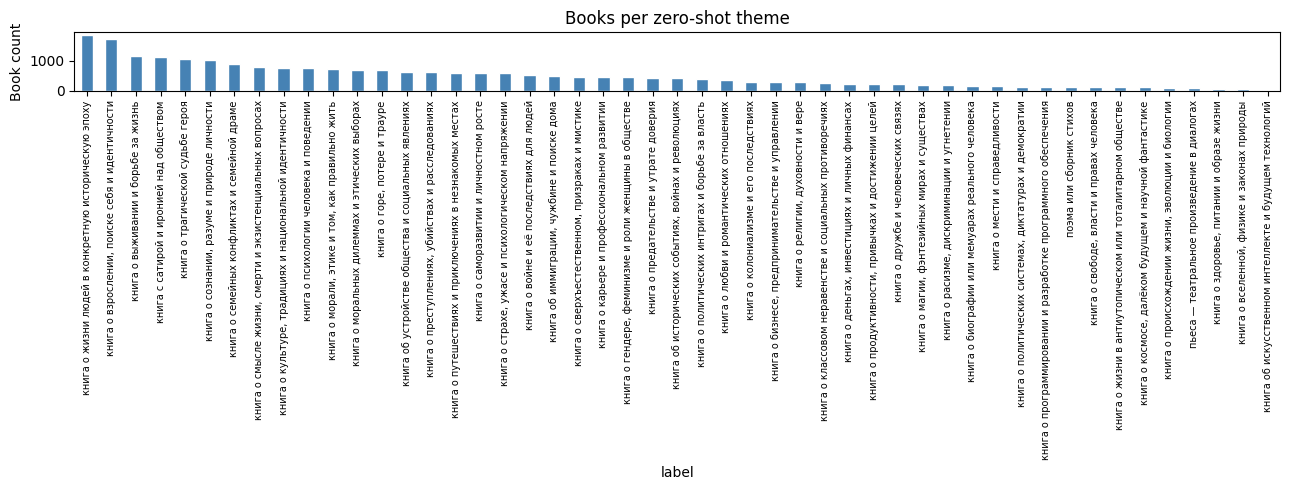

label
книга о жизни людей в конкретную историческую эпоху               1872
книга о взрослении, поиске себя и идентичности                    1728
книга о выживании и борьбе за жизнь                               1152
книга с сатирой и иронией над обществом                           1126
книга о трагической судьбе героя                                  1050
книга о сознании, разуме и природе личности                       1023
книга о семейных конфликтах и семейной драме                       884
книга о смысле жизни, смерти и экзистенциальных вопросах           783
книга о культуре, традициях и национальной идентичности            777
книга о психологии человека и поведении                            749
книга о морали, этике и том, как правильно жить                    734
книга о моральных дилеммах и этических выборах                     710
книга о горе, потере и трауре                                      710
книга об устройстве общества и социальных явлениях                 640


In [29]:
theme_counts = df_scores['label'].value_counts()

fig, ax = plt.subplots(figsize=(13, 5))
theme_counts.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Books per zero-shot theme')
ax.set_ylabel('Book count')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

print(theme_counts.to_string())

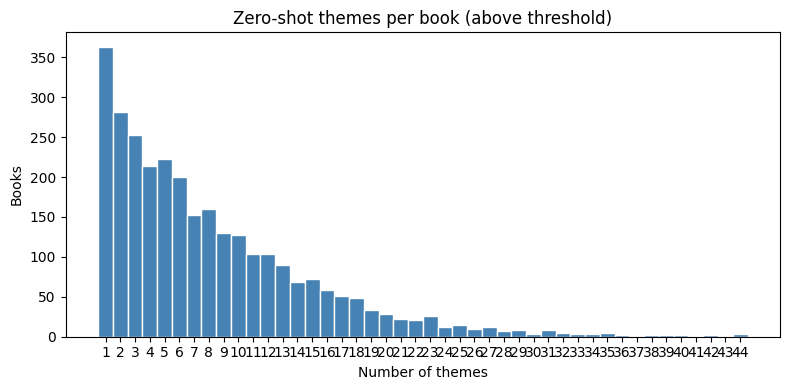

count    2938.00
mean        8.11
std         6.90
min         1.00
25%         3.00
50%         6.00
75%        11.00
max        44.00
Name: label, dtype: float64


In [54]:
themes_per_book = df_scores.groupby('book_id')['label'].count()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(themes_per_book, bins=range(1, themes_per_book.max() + 2),
        edgecolor='white', color='steelblue', align='left')
ax.set_title('Zero-shot themes per book (above threshold)')
ax.set_xlabel('Number of themes')
ax.set_ylabel('Books')
ax.set_xticks(range(1, themes_per_book.max() + 1))
plt.tight_layout()
plt.show()

print(themes_per_book.describe().round(2))


## 3. BERTopic cluster analysis

BERTopic classified books : 649
Unique cluster labels     : 14


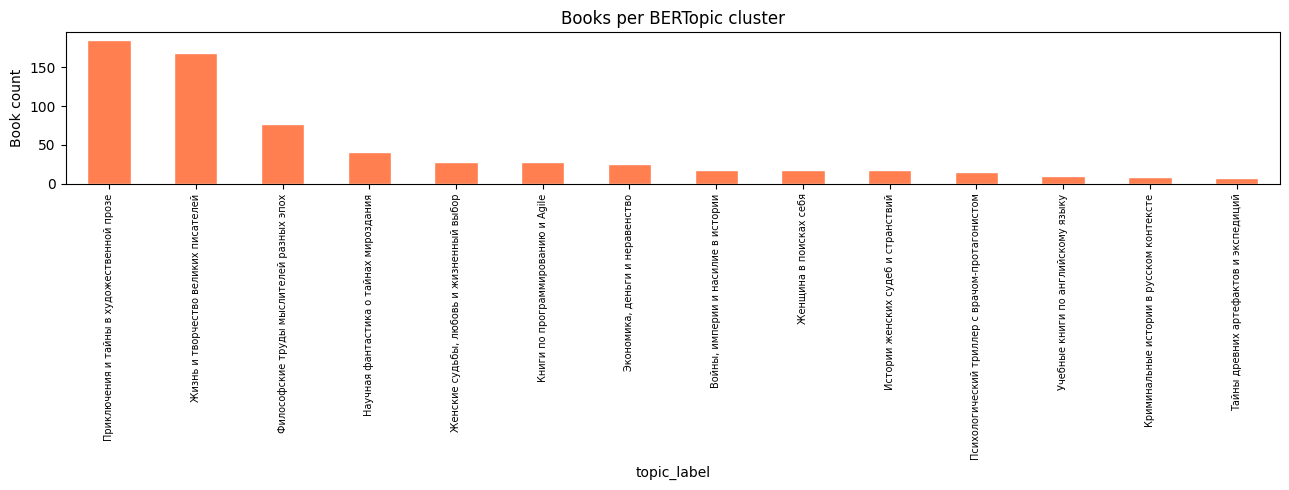

topic_label
Приключения и тайны в художественной прозе        186
Жизнь и творчество великих писателей              168
Философские труды мыслителей разных эпох           77
Научная фантастика о тайнах мироздания             41
Женские судьбы, любовь и жизненный выбор           28
Книги по программированию и Agile                  28
Экономика, деньги и неравенство                    25
Войны, империи и насилие в истории                 18
Женщина в поисках себя                             18
Истории женских судеб и странствий                 18
Психологический триллер с врачом-протагонистом     15
Учебные книги по английскому языку                 10
Криминальные истории в русском контексте            9
Тайны древних артефактов и экспедиций               8


In [30]:
df_bt = df_raw[df_raw['source'] == 'bertopic'].copy()
df_bt['topic_label'] = df_bt['tags'].apply(lambda x: x.get('topic_label', 'unknown'))
df_bt['bertopic_words'] = df_bt['tags'].apply(lambda x: x.get('bertopic_words', []))

print(f"BERTopic classified books : {len(df_bt):,}")
print(f"Unique cluster labels     : {df_bt['topic_label'].nunique()}")

cluster_sizes = df_bt['topic_label'].value_counts()

fig, ax = plt.subplots(figsize=(13, 5))
cluster_sizes.plot.bar(ax=ax, color='coral', edgecolor='white')
ax.set_title('Books per BERTopic cluster')
ax.set_ylabel('Book count')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

print(cluster_sizes.to_string())

##  Validation sample

In [ ]:
df_scores.head()


In [ ]:
import os
import json
from datetime import datetime, timezone

BUDGET = 250
N_MIN  = 3
SEED   = 42
SAMPLE_PATH = "validation/sample.json"

top5_per_book = (
    df_scores.sort_values(['book_id', 'score'], ascending=[True, False])
    .groupby('book_id')
    .head(5)
)

book_top5 = {}
for book_id, grp in top5_per_book.groupby('book_id'):
    book_top5[book_id] = list(zip(grp['label'], grp['score']))

print(f"Books with at least 1 above-threshold theme: {len(book_top5):,}")

theme_counts = Counter()
for themes in book_top5.values():
    for theme, _ in themes:
        theme_counts[theme] += 1

n_books_total = len(book_top5)
theme_prevalence = {t: c / n_books_total for t, c in theme_counts.items()}

print(f"\nThemes appearing in at least one top-5: {len(theme_prevalence)}")
print("\nTop 10 by prevalence:")
for t, p in sorted(theme_prevalence.items(), key=lambda x: -x[1])[:10]:
    print(f"  {p:.3f}  {t}")


In [ ]:
rng = np.random.default_rng(SEED)


total_prev = sum(theme_prevalence.values())
c = BUDGET / total_prev  # initial estimate, may overshoot due to N_MIN floor

def compute_allocations(c):
    return {t: max(N_MIN, round(p * c)) for t, p in theme_prevalence.items()}

# Iterate c to land close to budget 
for _ in range(1000):
    alloc = compute_allocations(c)
    total = sum(alloc.values())
    if total <= BUDGET:
        break
    c *= BUDGET / total

print(f"Scale factor c = {c:.2f}")
print(f"Planned total allocations: {sum(alloc.values())} (budget: {BUDGET})")
print(f"\nPer-theme allocations (sorted by n desc):")
for t, n in sorted(alloc.items(), key=lambda x: -x[1]):
    print(f"  n={n:3d}  prev={theme_prevalence[t]:.3f}  {t}")
theme_to_books = {}
for book_id, themes in book_top5.items():
    for theme, _ in themes:
        theme_to_books.setdefault(theme, []).append(book_id)

# book_id -> set of themes it was sampled for
sampled_for: dict[int, set] = {}

for theme, n_h in alloc.items():
    candidates = theme_to_books.get(theme, [])
    if not candidates:
        continue
    k = min(n_h, len(candidates))
    chosen = rng.choice(candidates, size=k, replace=False).tolist()
    for book_id in chosen:
        sampled_for.setdefault(book_id, set()).add(theme)

print(f"\nUnique books in sample: {len(sampled_for)}")

id_to_meta = df_raw.set_index('id')[['title', 'description']].to_dict('index')

records = []
for book_id, themes_set in sampled_for.items():
    meta   = id_to_meta.get(book_id, {})
    top5   = book_top5.get(book_id, [])
    records.append({
        "book_id":            int(book_id),
        "title":              meta.get('title', ''),
        "description":        meta.get('description', ''),
        "sampled_for_themes": sorted(themes_set),
        "nli_top5":           [t for t, _ in top5],
        "nli_top5_scores":    [round(float(s), 4) for _, s in top5],
    })

records.sort(key=lambda r: r['book_id'])

output = {
    "metadata": {
        "created":      datetime.now(timezone.utc).isoformat(),
        "budget":       BUDGET,
        "n_min":        N_MIN,
        "seed":         SEED,
        "actual_count": len(records),
    },
    "books": records,
}

os.makedirs("validation", exist_ok=True)
with open(SAMPLE_PATH, "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Saved {len(records)} books → {SAMPLE_PATH}")


In [ ]:
# For each book, find the top-ranked theme (highest NLI score)
top_theme_per_book = (
    df_scores.sort_values('score', ascending=False)
    .groupby('book_id')
    .first()
    .reset_index()[['book_id', 'label']]
)

top_theme_counts = top_theme_per_book['label'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, max(5, len(top_theme_counts) * 0.35)))
top_theme_counts.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('How often each theme is the top-ranked theme for a book')
ax.set_xlabel('Number of books')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

print(top_theme_counts.sort_values(ascending=False).to_string())


## 11. Cosine similarity top-5 (validation books)

In [43]:
from sentence_transformers import SentenceTransformer

COSINE_PATH  = "validation/cosine_top5.json"
EMBED_MODEL  = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

with open(SAMPLE_PATH, encoding="utf-8") as f:
    sample_data = json.load(f)
sample_books = sample_data["books"]
print(f"Validation sample: {len(sample_books)} books")

if "word_model" not in dir():
    word_model = SentenceTransformer(EMBED_MODEL)

theme_vecs = word_model.encode(ALL_THEMES, normalize_embeddings=True, show_progress_bar=False)
theme_vecs = np.array(theme_vecs, dtype=np.float32)   
descriptions = [b["description"] for b in sample_books]
desc_vecs = word_model.encode(
    descriptions, normalize_embeddings=True,
    show_progress_bar=True, batch_size=32,
)
desc_vecs = np.array(desc_vecs, dtype=np.float32)     # (n_books, d)

# dot product of desc_vec and theme vec (transpose for TV to e column) 
cos_matrix = desc_vecs @ theme_vecs.T                 # (n_books, n_themes)

cosine_top5 = {}
for i, book in enumerate(sample_books):
    sims    = cos_matrix[i]
    top_idx = np.argsort(sims)[::-1][:5]
    cosine_top5[book["book_id"]] = [
        {"theme": ALL_THEMES[j], "score": round(float(sims[j]), 4)}
        for j in top_idx
    ]

os.makedirs("validation", exist_ok=True)
with open(COSINE_PATH, "w", encoding="utf-8") as f:
    json.dump(cosine_top5, f, ensure_ascii=False, indent=2)
print(f"Saved → {COSINE_PATH}")

Validation sample: 237 books


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Saved → validation/cosine_top5.json
  ✓  [2783] Записки о Шерлоке Холмсе (сборник)
      NLI : книга о преступлениях, убийствах и расследованиях
      COS : книга о преступлениях, убийствах и расследованиях
  ✓  [2300] Все московские повести (сборник)
      NLI : книга о жизни людей в конкретную историческую эпоху
      COS : книга о жизни людей в конкретную историческую эпоху
  ✗  [1341] Корабль-призрак
      NLI : книга о выживании и борьбе за жизнь
      COS : книга о трагической судьбе героя
  ✓  [1494] Сильмариллион
      NLI : книга о магии, фэнтезийных мирах и существах
      COS : книга о магии, фэнтезийных мирах и существах
  ✓  [7725] Озабоченность статусом
      NLI : книга об устройстве общества и социальных явлениях
      COS : книга об устройстве общества и социальных явлениях


## 12. Сравнение NLI и Cosine-Similarity

In [ ]:
Программа будет выдавать два списка тем, один создан с помощью NLI zero-shot, другой с помощью cosine-sim по описаниям.
Я должен оценить, какой из них лучше

In [45]:
import ipywidgets as w
from IPython.display import display, Javascript

PAIRWISE_PATH = "validation/pairwise_labels.json"

# ── Load data ─────────────────────────────────────────────────────────────────
with open(SAMPLE_PATH, encoding="utf-8") as f:
    sample_data = json.load(f)

with open(COSINE_PATH, encoding="utf-8") as f:
    _cos_raw = json.load(f)
cosine_top5_lbl = {int(k): v for k, v in _cos_raw.items()}

if os.path.exists(PAIRWISE_PATH):
    with open(PAIRWISE_PATH, encoding="utf-8") as f:
        pairwise_data = json.load(f)
else:
    pairwise_data = {
        "metadata": {"created": datetime.now(timezone.utc).isoformat(), "last_updated": ""},
        "judgments": [],
    }

already_labeled = {j["book_id"] for j in pairwise_data["judgments"]}
all_books       = sample_data["books"]
queue           = [b for b in all_books if b["book_id"] not in already_labeled]

# Fixed A/B assignment per book — stable across restarts
_ab_rng = np.random.default_rng(SEED + 99)
ab_assign = {}
for b in all_books:
    ab_assign[b["book_id"]] = ("nli", "cos") if _ab_rng.random() < 0.5 else ("cos", "nli")

state = {"idx": 0, "session_history": []}

# ── Helpers ───────────────────────────────────────────────────────────────────
def _theme_table(themes, scores, header):
    rows = "".join(
        f"<tr><td style='color:#999;padding:3px 8px 3px 0'>{i+1}.</td>"
        f"<td style='padding:3px 0;font-size:13px'>{t}</td>"
        f"<td style='color:#aaa;font-size:11px;padding:3px 0 3px 10px'>{s:.3f}</td></tr>"
        for i, (t, s) in enumerate(zip(themes, scores))
    )
    return (
        f"<div style='background:#f5f5f5;border-radius:6px;padding:12px 16px;height:100%'>"
        f"<b style='font-size:14px'>{header}</b>"
        f"<table style='margin-top:8px;border-collapse:collapse;width:100%'>{rows}</table></div>"
    )

def _save():
    pairwise_data["metadata"]["last_updated"] = datetime.now(timezone.utc).isoformat()
    with open(PAIRWISE_PATH, "w", encoding="utf-8") as f:
        json.dump(pairwise_data, f, ensure_ascii=False, indent=2)

# ── Widgets ───────────────────────────────────────────────────────────────────
w_progress = w.HTML()
w_desc     = w.HTML(layout=w.Layout(margin="8px 0"))
w_left     = w.HTML(layout=w.Layout(width="50%", padding="0 6px 0 0"))
w_right    = w.HTML(layout=w.Layout(width="50%", padding="0 0 0 6px"))
w_note     = w.Textarea(
    placeholder="Optional note…",
    layout=w.Layout(width="100%", height="48px", margin="6px 0 0 0"),
)

btn_specs = [
    ("A clearly better [1]", +2, "success"),
    ("A slightly better [2]", +1, "info"),
    ("Tie [3]",               0,  "warning"),
    ("B slightly better [4]", -1, "info"),
    ("B clearly better [5]",  -2, "danger"),
]
pref_btns = [
    w.Button(description=desc, button_style=style,
             layout=w.Layout(flex="1", min_width="130px"))
    for desc, _, style in btn_specs
]
back_btn = w.Button(description="← Back [b]", layout=w.Layout(width="120px"))
btn_bar  = w.HBox(
    [back_btn, w.HTML("<span style='width:10px;display:inline-block'></span>"), *pref_btns],
    layout=w.Layout(flex_flow="row wrap", gap="4px", margin="8px 0 4px 0"),
)
ui = w.VBox([
    w_progress, w_desc,
    w.HBox([w_left, w_right]),
    w.HTML("<hr style='margin:10px 0;border:none;border-top:1px solid #ddd'>"),
    btn_bar, w_note,
])

# ── Render ────────────────────────────────────────────────────────────────────
def render(idx):
    n_total   = len(queue)
    n_labeled = len(pairwise_data["judgments"])
    if idx >= n_total:
        w_progress.value = (
            f"<b style='color:green'>✓ All {n_total} books labeled!</b> "
            f"({n_labeled} total judgments saved)"
        )
        w_desc.value = w_left.value = w_right.value = ""
        return

    book           = queue[idx]
    bid            = book["book_id"]
    a_meth, b_meth = ab_assign[bid]

    nli_themes = book["nli_top5"]
    nli_scores = book["nli_top5_scores"]
    cos_data   = cosine_top5_lbl.get(bid, [])
    cos_themes = [d["theme"] for d in cos_data]
    cos_scores = [d["score"]  for d in cos_data]

    l_themes, l_scores = (nli_themes, nli_scores) if a_meth == "nli" else (cos_themes, cos_scores)
    r_themes, r_scores = (cos_themes, cos_scores) if b_meth == "cos" else (nli_themes, nli_scores)

    w_progress.value = (
        f"<b>Book {idx + 1} / {n_total}</b> &nbsp;·&nbsp; {n_labeled} labeled so far"
    )
    w_desc.value = (
        f"<div style='background:#fafafa;border-left:3px solid #ccc;"
        f"padding:10px 14px;border-radius:0 4px 4px 0;font-size:13px;line-height:1.65'>"
        f"<b style='font-size:15px'>{book['title']}</b><br><br>"
        f"{book['description']}</div>"
    )
    w_left.value  = _theme_table(l_themes, l_scores, "List A")
    w_right.value = _theme_table(r_themes, r_scores, "List B")
    w_note.value  = ""

# ── Callbacks ─────────────────────────────────────────────────────────────────
def on_pref(preference):
    idx = state["idx"]
    if idx >= len(queue):
        return
    book           = queue[idx]
    bid            = book["book_id"]
    a_meth, b_meth = ab_assign[bid]
    nli_signed     = preference if a_meth == "nli" else -preference

    pairwise_data["judgments"].append({
        "book_id":          bid,
        "left_method":      a_meth,
        "right_method":     b_meth,
        "preference":       preference,
        "nli_signed_score": nli_signed,
        "note":             w_note.value.strip(),
        "labeled_at":       datetime.now(timezone.utc).isoformat(),
    })
    _save()
    state["session_history"].append(idx)
    state["idx"] += 1
    render(state["idx"])

def on_back(_):
    if not state["session_history"]:
        return
    prev_idx = state["session_history"].pop()
    pairwise_data["judgments"].pop()
    _save()
    state["idx"] = prev_idx
    render(state["idx"])

back_btn.on_click(on_back)
for btn, (_, pref, __) in zip(pref_btns, btn_specs):
    btn.on_click(lambda _, p=pref: on_pref(p))

render(state["idx"])
display(ui)

display(Javascript("""
(function() {
  function handler(e) {
    if (e.target.tagName === 'TEXTAREA' || e.target.tagName === 'INPUT') return;
    const keyMap = {'1':0, '2':1, '3':2, '4':3, '5':4};
    if (e.key in keyMap) {
      const btns = Array.from(document.querySelectorAll('.widget-button'))
                       .filter(b => /\[\d\]/.test(b.textContent));
      if (btns[keyMap[e.key]]) { btns[keyMap[e.key]].click(); e.preventDefault(); }
    }
    if (e.key === 'b' || e.key === 'B') {
      const back = Array.from(document.querySelectorAll('.widget-button'))
                        .find(b => b.textContent.includes('Back'));
      if (back) { back.click(); e.preventDefault(); }
    }
  }
  if (window._pwHandler) document.removeEventListener('keydown', window._pwHandler);
  window._pwHandler = handler;
  document.addEventListener('keydown', handler);
})();
"""))


<IPython.core.display.Javascript object>

## 13. Сравнение NLI и Cosine-Similarity -- Результаты 

Judgments so far: 86 / 237


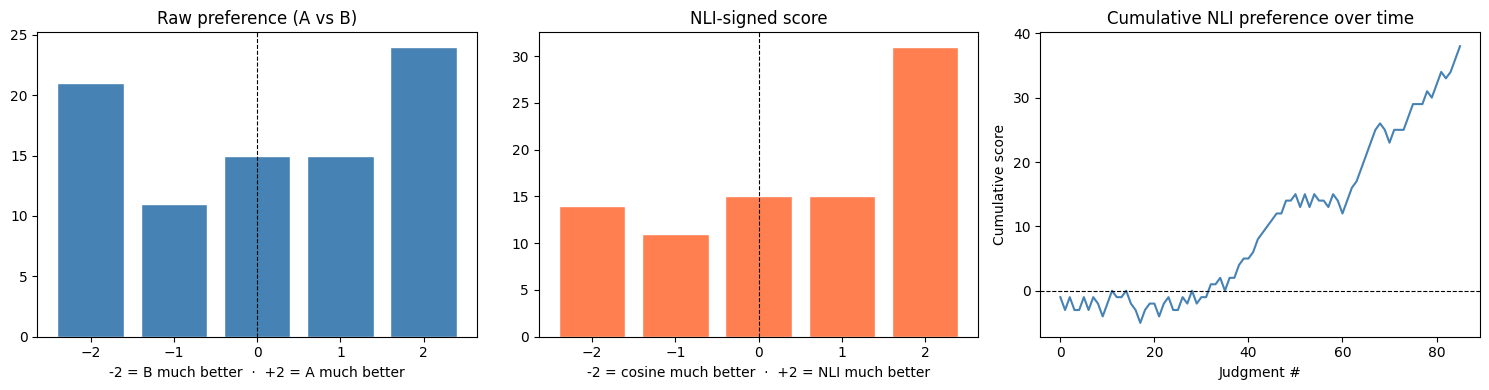


Mean NLI signed score : +0.442  (positive = NLI preferred)
NLI preferred         : 46 / 86  (53%)
Cosine preferred      : 25 / 86  (29%)
Ties                  : 15 / 86  (17%)


In [50]:
with open(PAIRWISE_PATH, encoding="utf-8") as f:
    pw = json.load(f)

df_pw = pd.DataFrame(pw["judgments"])
n = len(df_pw)
print(f"Judgments so far: {n} / {len(all_books)}")

if n == 0:
    print("No judgments yet.")
else:
    # ── Overall preference distribution ──────────────────────────────────────
    pref_counts = df_pw["preference"].value_counts().sort_index()
    nli_counts  = df_pw["nli_signed_score"].value_counts().sort_index()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].bar(pref_counts.index, pref_counts.values, color="steelblue", edgecolor="white")
    axes[0].axvline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0].set_title("Raw preference (A vs B)")
    axes[0].set_xlabel("-2 = B much better  ·  +2 = A much better")
    axes[0].set_xticks([-2, -1, 0, 1, 2])

    axes[1].bar(nli_counts.index, nli_counts.values, color="coral", edgecolor="white")
    axes[1].axvline(0, color="black", linestyle="--", linewidth=0.8)
    axes[1].set_title("NLI-signed score")
    axes[1].set_xlabel("-2 = cosine much better  ·  +2 = NLI much better")
    axes[1].set_xticks([-2, -1, 0, 1, 2])

    # Cumulative NLI preference over judgments
    axes[2].plot(df_pw["nli_signed_score"].cumsum().values, color="steelblue")
    axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[2].set_title("Cumulative NLI preference over time")
    axes[2].set_xlabel("Judgment #")
    axes[2].set_ylabel("Cumulative score")

    plt.tight_layout()
    plt.show()

    # ── Summary stats ─────────────────────────────────────────────────────────
    mean_nli   = df_pw["nli_signed_score"].mean()
    nli_wins   = (df_pw["nli_signed_score"] > 0).sum()
    cos_wins   = (df_pw["nli_signed_score"] < 0).sum()
    ties       = (df_pw["nli_signed_score"] == 0).sum()

    print(f"\nMean NLI signed score : {mean_nli:+.3f}  (positive = NLI preferred)")
    print(f"NLI preferred         : {nli_wins} / {n}  ({100*nli_wins/n:.0f}%)")
    print(f"Cosine preferred      : {cos_wins} / {n}  ({100*cos_wins/n:.0f}%)")
    print(f"Ties                  : {ties} / {n}  ({100*ties/n:.0f}%)")
    if df_pw["note"].str.strip().astype(bool).any():
        print(f"\nJudgments with notes  : {df_pw['note'].str.strip().astype(bool).sum()}")
